# DỰ ÁN AI: ỨNG DỤNG THỰC TẾ (INFERENCE)
Khác với file `train.ipynb` - nơi chúng ta phải mất nhiều thời gian để "chế tạo" AI, file `predict.ipynb` này là **sản phẩm đầu cuối** để mang ra trình diễn thực tiễn.

Cơ chế hoạt động cực kỳ đơn giản: 
Nó sẽ nạp "bộ não" (`best_model.pth`) đã được rèn luyện từ bài trước vào. Sau đó, nó sẵn sàng nhận bất kỳ một bức ảnh mới nào (ví dụ tải từ trên mạng về) và đưa ra phán đoán đó là Xe máy hay Xe đạp cực kỳ nhanh chóng.

### BƯỚC 1: Khai báo thư viện & Nạp trọng số (Load Model)
Phần này sẽ khởi tạo lại cấu trúc thân xác (ResNet50 với Output là 2) giống hệt với lúc học, và chép bộ nhớ `best_model.pth` vào thân xác đó.

In [1]:
import os
import torch
import torch.nn as nn
from torchvision import transforms
import torchvision.models as tv_models
from PIL import Image
import matplotlib.pyplot as plt
import urllib.request # Dùng để tải ảnh tự động trên mạng về demo

# 1. Tìm đường dẫn file bộ não
PROJECT_DIR = os.path.abspath(os.getcwd())
MODEL_PATH = os.path.join(PROJECT_DIR, 'best_model.pth')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Hệ thống đang chạy trên: {device}')

def load_model():
    if not os.path.exists(MODEL_PATH):
        print(f'LỖI: Không tìm thấy file não bộ {MODEL_PATH}. Vui lòng chạy file train.ipynb trước để tạo ra nó!')
        return None
        
    # Tạo lại hình hài cơ thể giống lúc học (ResNet50, 2 đáp án cuối)
    model = tv_models.resnet50()
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 2)
    
    # Nhét linh hồn (Trọng số) vào cơ thể
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
    model.to(device)
    model.eval() # Chuyển công tắc AI sang chế độ Ứng dụng thực tế (Không học hỏi thêm)
    return model

model = load_model()
if model:
    print('Đã lắp ráp AI thành công. Sẵn sàng dự đoán!')

Hệ thống đang chạy trên: cuda
Đã lắp ráp AI thành công. Sẵn sàng dự đoán!


### BƯỚC 2: Tiền xử lý ảnh đầu vào & Suy luận
Máy tính không thể "nhìn" bức ảnh như con người. Nó chỉ hiểu các con số ma trận.
Bởi vậy, một bức ảnh chụp từ điện thoại hay lấy trên internet về **BẮT BUỘC** phải được bóp méo (Resize) về kích thước 224x224 và biến đổi màu (Normalize) **GIỐNG HỆT** như các tham số cài đặt lúc tập Train thì AI mới nhận diện chính xác được.

Cuối cùng, ta dùng hàm toán học `Softmax` để chuyển điểm số do AI tính ra thành số phần trăm (%) mức độ tự tin để con người dễ hiểu.

In [2]:
def predict_image(image_path, model):
    class_names = ['Bike', 'Motorbike']
    
    # 1. Ép bức ảnh đưa vào về cùng một Form giống hệt lúc Train/Val
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    try:
        image = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f'[!] Lỗi không thể đọc được file ảnh: {e}')
        return

    # Biến ảnh thành ma trận chuẩn bị đưa vào mạng (Thêm 1 chiều đại diện cho Lô - Batch size 1)
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    # 2. Suy Diễn
    with torch.no_grad(): # Tắt chức năng huấn luyện để tiết kiệm RAM
        outputs = model(input_tensor) # Kết quả xuất ra là Logits (Điểm số toán học thô)
        
        # Dùng hàm Softmax để ép các điểm số toán học thô về thang 0-100%
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
        
        # Lấy ra Vị trí có điểm số cao nhất (0 = Bike, 1 = Motorbike)
        _, preds = torch.max(outputs, 1)
        
        pred_class = class_names[preds[0]]
        confidence = probabilities[preds[0]].item() * 100
        
    # 3. Trực quan hoá kết quả
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'AI Dự Đoán: Đây là {pred_class} (Tự tin: {confidence:.2f}%)')
    plt.show()
    
    print(f'Chi tiết tính toán nội bộ: Bike ({probabilities[0]*100:.2f}%) | Motorbike ({probabilities[1]*100:.2f}%)')

### BƯỚC 3: Demo Thực tế
Phần này đã được thiết kế sẵn cho việc làm **Demo / Thuyết trình**.
Thay vì phải tự tải ảnh bằng tay, đoạn code dưới đây đã trang bị sẵn tính năng Failsafe: Nếu bạn không có sẵn ảnh `test_image.jpg` ở thư mục hiện tại, nó sẽ tự động chạy lên trang ảnh mẫu của thư viện Unsplash để tải một bức ảnh xe ngẫu nhiên về và chạy dự đoán luôn. Rất mượt mà và chống gián đoạn!

[*] Chú ý: Không tìm thấy ảnh 'test_image.jpg' trong thư mục.
[*] Để tránh mất thời gian, hệ thống đang tự động tải ảnh 1 chiếc xe trên mạng về làm mẫu...
[*] Đã chuẩn bị xong ảnh mẫu!

=== BẮT ĐẦU CHẠY SUY LUẬN (FORWARD PASS) ===


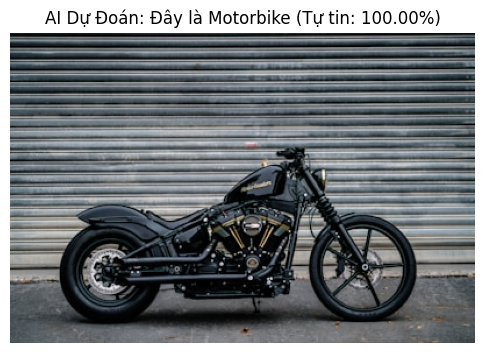

Chi tiết tính toán nội bộ: Bike (0.00%) | Motorbike (100.00%)


In [3]:
if model:
    # Bạn hoàn toàn có thể tự lưu một bức ảnh trên Google đặt tên là 'test_image.jpg' vào thư mục và chạy
    test_image_path = 'test_image.jpg'
    
    # === KỊCH BẢN FAILSAFE ===
    # Nếu không tìm thấy ảnh của bạn, code tự động lấy 1 ảnh ngẫu nhiên trên mạng làm ví dụ.
    if not os.path.exists(test_image_path):
        print(f"[*] Chú ý: Không tìm thấy ảnh '{test_image_path}' trong thư mục.")
        print("[*] Để tránh mất thời gian, hệ thống đang tự động tải ảnh 1 chiếc xe trên mạng về làm mẫu...")
        
        # Đường dẫn 1 bức ảnh xe máy ngẫu nhiên trên Unsplash
        sample_url = "https://images.unsplash.com/photo-1558981285-6f0c94958bb6?w=400" 
        try:
            urllib.request.urlretrieve(sample_url, test_image_path)
            print("[*] Đã chuẩn bị xong ảnh mẫu!\n")
        except Exception as e:
            print(f"[!] Lỗi khi tự tải ảnh (Có thể do mất mạng): {e}")
            
    # Bắt đầu suy diễn
    if os.path.exists(test_image_path):
        print("=== BẮT ĐẦU CHẠY SUY LUẬN (FORWARD PASS) ===")
        predict_image(test_image_path, model)